In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
!gdown 1nrKDzTkuEKm887q7yxUmeGk7GhjDNhzM

Downloading...
From: https://drive.google.com/uc?id=1nrKDzTkuEKm887q7yxUmeGk7GhjDNhzM
To: /content/housing.csv
100% 1.42M/1.42M [00:00<00:00, 36.7MB/s]


In [3]:
df = pd.read_csv('/content/housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df = df.drop(columns=['ocean_proximity'])

In [19]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [7]:
df = df.dropna()

In [18]:
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']
# print(y)

In [9]:
X.shape

(20433, 8)

In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [12]:
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [13]:
class my_NN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(X_train.shape[1], 50)
    self.layer2 = nn.Linear(50, 30)
    self.layer3 = nn.Linear(30, 1)

  def forward(self, x):
    x = self.layer1(x)
    x = nn.functional.sigmoid(x)
    x = self.layer2(x)
    x = nn.functional.sigmoid(x)
    x = self.layer3(x)
    return x

In [14]:
lr = 1e-3
mm = 0.5
epochs = 100

model = my_NN()
opt = optim.SGD(model.parameters(), lr=lr, momentum=mm)
loss_fn = nn.MSELoss()

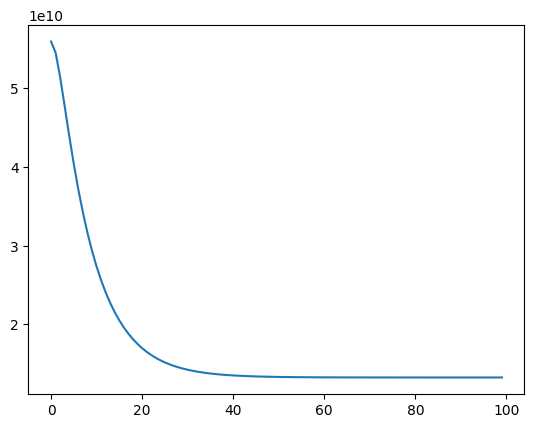

In [15]:
ls = []

for i in range(epochs):
  # forward pass
  yhat = model(X_train)
  loss = loss_fn(yhat, y_train.view(-1, 1))

  # backward pass
  loss.backward()
  opt.step()
  opt.zero_grad()

  ls.append(loss.item())

plt.plot(ls)

In [16]:

# forward pass
yhat = model(X_test)
test_loss = loss_fn(yhat, y_test.view(-1, 1))

print(test_loss.item())
print(loss.item())

13677128704.0
13236978688.0
